<a href="https://colab.research.google.com/github/EnricoABM/umc-ia/blob/main/Atividade_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enrico de Andrade Bertozzi Miranda - RGM 11231100657

Curso: Engenharia de Software

Disciplina: Inteligência Artificial

Turma: 6A

Professor: Dr. Fabiano Bezerra Menegidio

# Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc, precision_recall_curve

import xgboost as xgb

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
titanic = sns.load_dataset('titanic')

df = titanic[['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch', 'embarked', 'survived']].copy()

df.head()

,pclass,sex,age,fare,sibsp,parch,embarked,survived
0,3,male,22.0,7.2500,1,0,S,0
1,1,female,38.0,71.2833,1,0,C,1
2,3,female,26.0,7.9250,0,0,S,1
3,1,female,35.0,53.1000,1,0,S,1
4,3,male,35.0,8.0500,0,0,S,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    891 non-null    int64  
 1   sex       891 non-null    object 
 2   age       714 non-null    float64
 3   fare      891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   embarked  889 non-null    object 
 7   survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


# Tratamento dos dados

In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())

In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    889 non-null    int64  
 1   sex       889 non-null    object 
 2   age       889 non-null    float64
 3   fare      889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   embarked  889 non-null    object 
 7   survived  889 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


# Engenharia de Atributos

In [ ]:
ohe_columns = ['sex', 'embarked', 'pclass']
std_columns = ['age', 'fare', 'sibsp', 'parch']

In [ ]:
df['familysize'] = df['sibsp'] + df['parch'] + 1

std_columns.append('familysize')

In [ ]:
df['isalone'] = df['sibsp'] == 0

df['isalone'] = df['isalone'].astype(int)
std_columns.append('isalone')

# Separação dos Dados

In [ ]:

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), ohe_columns),
    ('std', StandardScaler(), std_columns)
], remainder='passthrough')

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

# Treino dos Modelos

## SVM (RBF)

In [ ]:
# SVM
rs_svm = RandomizedSearchCV(
    SVC(random_state=42, kernel='rbf', probability=True),
    param_distributions={
        'C': [0.1, 1, 10, 20, 50, 100],
        'gamma': ['scale', 0.1, 1, 10, 20, 50, 100],
    },
    n_jobs=-1,
    cv=cv,
    scoring='roc_auc',
    random_state=42
)

rs_svm.fit(X_train, y_train)

y_proba_svm = rs_svm.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_svm = rs_svm.predict(X_test)

In [ ]:
# Métricas

acc_train_svm = cross_val_score(rs_svm.best_estimator_, X_train, y_train, cv=cv, scoring='accuracy').mean()
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

In [ ]:
# Curva ROC-AUC

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_proba_svm)

In [ ]:
# Precision Recall Curve

precision_svm, recall_svm, thresholds_svm = precision_recall_curve(y_test, y_proba_svm)
pr_auc_svm = auc(recall_svm, precision_svm)

## Random Forest

In [ ]:
# RandomForest
rs_rfc = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions={
        'n_estimators': [100, 200, 300, 500, 1000],
        'max_depth': [None, 5, 10, 20, 30],
        'min_samples_leaf': [1, 2, 5, 10, 20],
    },
    n_jobs=-1,
    cv=cv,
    scoring='roc_auc',
    random_state=42
)

rs_rfc.fit(X_train, y_train)

y_proba_rfc = rs_rfc.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_rfc = rs_rfc.predict(X_test)

In [ ]:
# Métricas

acc_train_rfc = cross_val_score(rs_rfc.best_estimator_, X_train, y_train, cv=cv, scoring='accuracy').mean()
acc_rfc = accuracy_score(y_test, y_pred_rfc)
f1_rfc = f1_score(y_test, y_pred_rfc)
auc_rfc = roc_auc_score(y_test, y_proba_rfc)

In [ ]:
# Curva ROC-AUC

fpr_rfc, tpr_rfc, thresholds_rfc = roc_curve(y_test, y_proba_rfc)

In [ ]:
# Curva Precision Recall

precision_rfc, recall_rfc, thresholds_rfc = precision_recall_curve(y_test, y_proba_rfc)
pr_auc_rfc = auc(recall_rfc, precision_rfc)

## XGBoost

In [ ]:
# XGBoost
rs_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='auc'),
    param_distributions={
        'n_estimators': [100, 200, 300, 500, 1000],
        'max_depth': [None, 5, 10, 20, 30],
        'min_child_weight': [1, 2, 5, 10, 20],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    },
    random_state=42,
    n_jobs=-1,
    cv=cv,
    scoring='roc_auc'
)

rs_xgb.fit(X_train, y_train)

y_proba_xgb = rs_xgb.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_xgb = rs_xgb.predict(X_test)

In [ ]:
# Métricas

acc_train_xgb = cross_val_score(rs_xgb.best_estimator_, X_train, y_train, cv=cv, scoring='accuracy').mean()
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

In [ ]:
# Curva ROC-AUC

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)

In [ ]:
# Curva Precision Recall

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

# Métricas

In [ ]:
metrics = {
    'SVM': [acc_train_svm, acc_svm, precision_svm.mean(), recall_svm.mean(), pr_auc_svm, auc_svm],
    'Random Forest': [acc_train_rfc, acc_rfc, precision_rfc.mean(), recall_rfc.mean(), pr_auc_rfc, auc_rfc],
    'XGBoost': [acc_train_xgb, acc_xgb, precision_xgb.mean(), recall_xgb.mean(), pr_auc_xgb, auc_xgb,]
}

df_metrics = pd.DataFrame(metrics, index=['Acurácia (Treino)', 'Acurácia (Teste)', 'Precision', 'Recall', 'Recall-Precision', 'ROC'])
df_metrics = df_metrics.map(lambda x: round(x, 4)*100)
df_metrics.T

,Acurácia (Treino),Acurácia (Teste),Precision,Recall,Recall-Precision,ROC
SVM,82.00,81.46,64.57,69.46,75.76,83.39
Random Forest,81.15,80.90,68.90,71.09,83.55,86.88
XGBoost,84.24,83.15,66.42,71.42,78.09,87.49


## Curvas


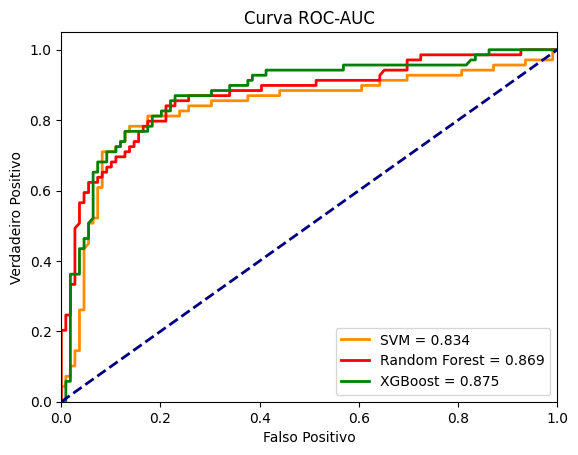

In [ ]:
# ROC-AUC

plt.figure()

plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'SVM = {auc_svm:.3f}')
plt.plot(fpr_rfc, tpr_rfc, color='red', lw=2, label=f'Random Forest = {auc_rfc:.3f}')
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'XGBoost = {auc_xgb:.3f}')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.title('Curva ROC-AUC')
plt.legend(loc="lower right")
plt.show()

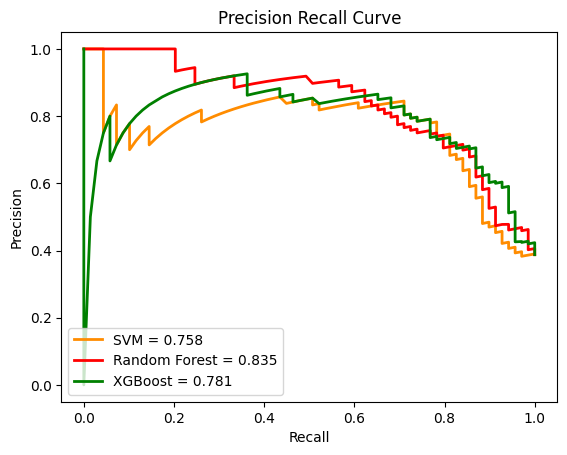

In [ ]:
# Precision Recall
plt.figure()

plt.plot(recall_svm, precision_svm, color='darkorange', lw=2, label=f'SVM = {pr_auc_svm:.3f}')
plt.plot(recall_rfc, precision_rfc, color='red', lw=2, label=f'Random Forest = {pr_auc_rfc:.3f}')
plt.plot(recall_xgb, precision_xgb, color='green', lw=2, label=f'XGBoost = {pr_auc_xgb:.3f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')
plt.legend(loc="lower left")
plt.show()

## Matrix de Confusão

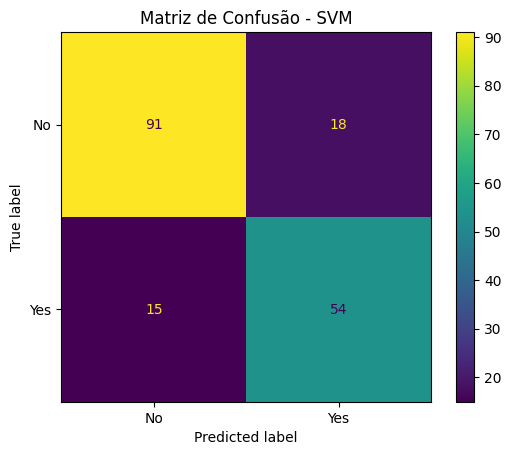

In [ ]:
# Matriz de Confusão SVM
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=['No', 'Yes'])
plt.title('Matriz de Confusão - SVM')
plt.show()

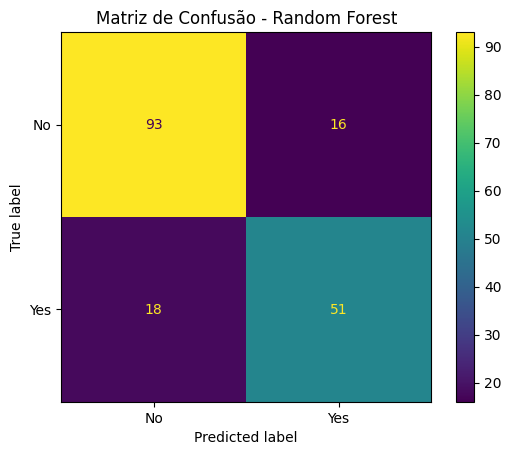

In [ ]:
# Matriz de Confusão RFC
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rfc, display_labels=['No', 'Yes'])
plt.title('Matriz de Confusão - Random Forest')
plt.show()

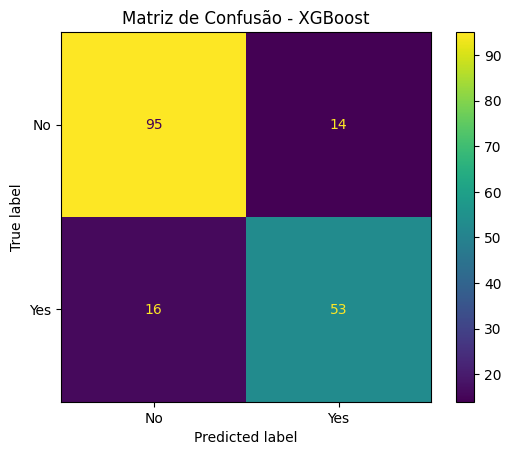

In [ ]:
# Matriz de Confusão XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=['No', 'Yes'])
plt.title('Matriz de Confusão - XGBoost')
plt.show()

# Discussão

* Qual modelo apresentou melhor desempenho?
> O modelo que demonstrou o melhor desempenho, levando em consideração a métrica ROC, foi o XGBoost, com 87,49. No entanto, o modelo Random Forest obteve o melhor balanceamento entre suas métricas.

* Algum modelo mostrou sinais de overfitting?
> Foram realizados testes de validação cruzada entre os dados de treino e teste para cada modelo. As acurácias obtidas com os dados de treino foram muito similares aos valores obtidos com os dados de teste. Evidenciando que não houve overfitting em nenhum dos modelos.

* Quais foram as dificuldades no pré-processamento?
> Foi necessário a conversão de todos os dados categóricos em valores numéricos, porém facilmente resolvido utilizando ColumnTransformer.